HHU Deep Learning in Life Sciences: Generative Models
**Professor:** Dr. Markus Kollmann | **Semester:** WS 2025-2026  
**Tutors:** Felix Michels and Adaloglou Nikolaos


## Assignment 5: Diffusion Model Sampling with Guidance Techniques



### 📋 Prerequisites & Setup and 📤 Submission Guidelines
- **Model checkpoints:** Available at `https://nvlabs-fi-cdn.nvidia.com/edm2/raw-snapshots/`
- **Deadline:** Thursday, January 22, 2025
- **Submission portal:** [Click here to submit](https://uni-duesseldorf.sciebo.de/s/7MKJgxRFNexm7HQ)
- **File naming:** `FIRSTNAME_LASTNAME_a5.ipynb` (e.g., `max_mustermann_a5.ipynb`)
- **Note**: `Rename` your file BEFORE submitting!
- **Format:** Submit only the solved notebook file (no zip archives)
- **Questions:** Post in the group chat if you encounter issues that might affect other students

### 🎲 Understanding Seeds
Seeds control the random noise generation for reproducible results. Each seed produces a specific image when using identical code parameters. This ensures consistent outputs for debugging and comparison purposes.

### Download files from sciebo link and unzip.
The above two system commands were tested for google colab.


In [1]:
#!wget https://uni-duesseldorf.sciebo.de/s/4W5cRgtjwK9i9GZ/download/libs.zip
#!unzip libs.zip

In [1]:
import os
import sys
import warnings
import torch
import numpy as np
from pathlib import Path
sys.path.insert(0, str(Path('./libs').resolve()))
import dnnlib
from PIL import Image
import matplotlib.pyplot as plt
import re
import pickle
import json
from torch_utils.misc import initialize_single_gpu, StackedRandomGenerator

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', '`resume_download` is deprecated')
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name()}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

os.makedirs("checkpoints", exist_ok=True)

seed_list = [3079,3618,13754,13443,7411,15645,7899,7522,13847,13911,18337,10465,11791,17541,17605,1084]

Libraries imported successfully!
PyTorch version: 2.9.1+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5080
CUDA memory: 15.9 GB



### 🔽 Download Pre-trained Model Checkpoints

This section downloads three EDM2 model variants for different guidance experiments:

1. **EDM2-S Full Training** (`edm2-img512-s-2147483-0.100.pkl`): Fully trained model with T=2.1M iterations
2. **EDM2-S Reduced Training** (`edm2-img512-s-0134217-0.100.pkl`): Early checkpoint with 134K (T/16) iterations (for weak model guidance)
3. **EDM2-XS Unconditional** (`edm2-img512-xs-uncond-2147483-0.100.pkl`): Smaller unconditional model (for classifier-free guidance)

**Note:** For higher quality results, consider using the larger EDM2-XXL model (requires more GPU memory).


In [3]:
!wget -N -P checkpoints https://nvlabs-fi-cdn.nvidia.com/edm2/raw-snapshots/edm2-img512-s/edm2-img512-s-2147483-0.100.pkl
!wget -N -P checkpoints https://nvlabs-fi-cdn.nvidia.com/edm2/raw-snapshots/edm2-img512-s/edm2-img512-s-0134217-0.100.pkl
!wget -N -P checkpoints https://nvlabs-fi-cdn.nvidia.com/edm2/raw-snapshots/edm2-img512-xs-uncond/edm2-img512-xs-uncond-2147483-0.100.pkl

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.



### 📁 ImageNet-1K Class Labels Setup

We use the ImageNet class index file containing 1,000 class names and their corresponding indices. This file maps numerical class IDs to human-readable labels for better result interpretation.

**Required file:** `ImageNet_class_index.json`  
**Source:** Available in the provided Sciebo folder or from the original repository https://github.com/Jasonlee1995/ImageNet-1K/blob/main/ImageNet_class_index.json

In [2]:
# read json with ImageNet classes
with open('./ImageNet_class_index.json', 'r') as f:
    imagenet_classes = json.load(f)

In [3]:
# Initialize device
device = initialize_single_gpu()
print(f"Device initialized: {device}")

Device initialized: cuda


# 🎯 Task 1: Implement Guidance Variations in EDM Sampler

Implement different guidance methods in the `compute_score` function within the EDM sampler. Each method modifies the score function to improve sample quality through different strategies.
- The function `swg_guidance` will be implemented later on in Task 2
- We generally denote the two difusion models as `net_pos` , `net_neg`

### Impement Variations in `compute_score`

- `g_method`: `none` --> no guidance
- `g_method`: `cfg` --> classifier-free guidance
- `g_method`: `swg` --> Sliding window guidance (SWG)
- `g_method`: `wmg` --> Weak model guidance (WMG) uses the so-called negative model which has inferior performance to the positive one, i.e. earlier checkpoint.
  - Call `y_neg, mask = swg_guidance(x, t, labels, net_pos, swg_sizes, swg_steps, dtype)`
  - The exact guidance equations for SWG depends on whether `masking` is 1 (True) or 0 (False).
  - The returned mask from the functions will be binary as shown in page 6 in https://arxiv.org/pdf/2411.10257



## Implementation Notes
- The `swg_guidance` function will be implemented in Task 2
- Apply guidance only within the specified `g_interval` steps
- Handle masking parameter for SWG variants



In [4]:
# SWG Guidance function
def swg_guidance(x, t, labels, net, swg_sizes, swg_steps, dtype):
    return None, None

# Core EDM sampler function with guidance support
def edm_sampler(
    net_pos, noise,
    labels=None, net_neg=None,
    num_steps=32, sigma_min=0.002, sigma_max=80, rho=7,
    S_churn=0, S_min=0, S_max=float('inf'), S_noise=1,
    dtype=torch.float32, randn_like=torch.randn_like,
    **cfg_kwargs,
):
    """
    EDM sampler with guidance support
    """
    def compute_score(x, t, i, labels, num_steps, g_weight, g_method, swg_sizes=None, swg_steps=None, g_interval=None,
                      masking=1):
        """Compute the score function at the point x and time t."""
        if g_interval == [] or g_interval is None:
            g_interval = [0, num_steps - 1]

        net_pos.img_resolution = x.shape[-1]
        y_pos = net_pos(x, t, labels).to(dtype)

        ### START CODE HERE ###
        # Check if guidance is enabled and within the specified interval
        if g_method != 'none' and g_interval[0] <= i <= g_interval[1]:
            y_neg = None
            mask = None

            # 1. Determine the negative score (y_neg) based on the method
            if g_method == 'cfg':
                # Classifier-Free Guidance: Use net_pos with unconditional (zero) labels
                # We assume labels are provided as a tensor; otherwise CFG is not applicable
                if labels is not None:
                    y_neg = net_pos(x, t, torch.zeros_like(labels)).to(dtype)

            elif g_method == 'wmg':
                # Weak Model Guidance: Use the negative/weaker model
                if net_neg is not None:
                    y_neg = net_neg(x, t, labels).to(dtype)

            elif g_method == 'swg':
                # Sliding Window Guidance: Use the utility function
                y_neg, mask = swg_guidance(x, t, labels, net_pos, swg_sizes, swg_steps, dtype)

            # 2. Apply the Guidance Equation
            if y_neg is not None:
                # Calculate the difference (guidance direction)
                diff = y_pos - y_neg

                # SWG Specific: Apply masking if enabled (masking=1) and mask exists
                if g_method == 'swg' and masking and mask is not None:
                    y_pos = y_pos + g_weight * (diff * mask)
                else:
                    # Standard linear guidance (CFG, WMG, or SWG without masking)
                    y_pos = y_pos + g_weight * diff
        ### END CODE HERE ###
        return y_pos # guided score

    cfg_kwargs['num_steps'] = num_steps
    # Time step discretization.
    step_indices = torch.arange(num_steps, dtype=dtype, device=noise.device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])]) # t_N = 0

    # Main sampling loop.
    x_next = noise.to(dtype) * t_steps[0]

    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])): # 0, ..., N-1
        x_cur = x_next

        # Increase noise temporarily.
        if S_churn > 0 and S_min <= t_cur <= S_max:
            gamma = min(S_churn / num_steps, np.sqrt(2) - 1)
            t_hat = t_cur + gamma * t_cur
            x_hat = x_cur + (t_hat ** 2 - t_cur ** 2).sqrt() * S_noise * randn_like(x_cur)
        else:
            t_hat = t_cur
            x_hat = x_cur

        # Euler step.
        d_cur = (x_hat - compute_score(x_hat, t_hat, i, labels, **cfg_kwargs)) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

        # Apply 2nd order correction.
        if i < num_steps - 1:
            d_prime = (x_next - compute_score(x_next, t_next, i+1, labels, **cfg_kwargs)) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)
    return x_next

print("EDM sampler function defined!")

EDM sampler function defined!


In [5]:
# Utility functions for image processing and display
def tensor_to_pil(tensor):
    """Convert tensor to PIL Image for display"""
    if tensor.dim() == 4:
        tensor = tensor[0]  # Take first image in batch

    # Normalize to [0, 1] if needed
    if tensor.min() < 0:
        tensor = (tensor + 1) / 2

    # Convert to numpy and transpose
    img_array = tensor.detach().cpu().numpy()
    img_array = np.transpose(img_array, (1, 2, 0))
    img_array = np.clip(img_array * 255, 0, 255).astype(np.uint8)

    return Image.fromarray(img_array)

def display_images(images, figsize=(10, 10), labels=None, save_name=None):
    """Display multiple images in a row"""
    if not isinstance(images, list):
        images = [images]

    num_images = len(images)
    fig, axes = plt.subplots(4, num_images//4, figsize=figsize)

    if num_images == 1:
        axes = [axes]

    for i, img in enumerate(images):
        if isinstance(img, torch.Tensor):
            img = tensor_to_pil(img)

        axes[i // 4, i % 4].imshow(img)
        axes[i // 4, i % 4].axis('off')
        if labels:
            axes[i // 4, i % 4].set_title(labels[i])

    plt.tight_layout()
    if save_name is not None:
        plt.savefig(save_name)
    plt.show()

def parse_int_list(s):
    """Parse comma-separated list of integers or ranges"""
    if isinstance(s, list):
        return s
    if s == "none":
        return []

    ranges = []
    range_re = re.compile(r'^(\d+)-(\d+)$')
    for p in s.split(','):
        m = range_re.match(p)
        if m:
            ranges.extend(range(int(m.group(1)), int(m.group(2))+1))
        else:
            ranges.append(int(p))
    return ranges

print("Utility functions defined!")

Utility functions defined!


In [6]:
# Redefining simple_sample with the fix
def simple_sample(
    config,
    seeds=[0, 1, 2, 3],
    device=None,
):
    config = dnnlib.EasyDict(config)

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Seeds: {seeds}")
    print(f"Guidance: {config.g_method} (weight: {config.g_weight})")

    # Load positive network
    print(f'Loading positive network from {config.net_pos_pkl} ...')
    with dnnlib.util.open_url(config.net_pos_pkl) as f:
        data = pickle.load(f)
    net_pos = data['ema'].to(device)

    # Load negative network ONLY if the path is provided (not None)
    net_neg = None
    # FIX IS HERE: Added check "and config.net_neg_pkl is not None"
    if config.g_method in ['cfg', 'wmg', 'wmg-swg'] and hasattr(config, 'net_neg_pkl') and config.net_neg_pkl is not None:
        print("Loading negative network...", config.net_neg_pkl)
        with dnnlib.util.open_url(config.net_neg_pkl) as f:
            data_neg = pickle.load(f)
        net_neg = data_neg['ema'].to(device)
    else:
        # For standard CFG where net_neg_pkl is None, we don't load anything.
        pass

    # Get encoder
    encoder = data.get('encoder', None)

    # Sampling parameters
    batch_size = len(seeds)
    img_resolution = getattr(net_pos, 'img_resolution', 512)
    num_channels = getattr(net_pos, 'img_channels', 3)

    # Generate noise
    rnd = StackedRandomGenerator(device, seeds)
    noise = rnd.randn([batch_size, num_channels, img_resolution, img_resolution], device=device)

    # Labels
    if config.class_idx is None:
        label_idx = rnd.randint(net_pos.label_dim, size=[batch_size], device=device)
    else:
        label_idx = torch.full([batch_size], config.class_idx, device=device)

    # Map to classes
    # Assuming imagenet_classes is defined in your environment
    try:
        label_classes = [imagenet_classes[str(idx)][-1] for idx in label_idx.tolist()]
    except:
        label_classes = [str(idx) for idx in label_idx.tolist()]

    labels = torch.eye(net_pos.label_dim, device=device)[label_idx]

    if config.g_interval is None:
        config.g_interval = [0, config.num_steps - 1]

    print("Starting sampling...")
    with torch.no_grad():
        samples = edm_sampler(
            net_pos=net_pos,
            noise=noise,
            labels=labels,
            net_neg=net_neg,
            num_steps=config.num_steps,
            g_method=config.g_method,
            g_weight=config.g_weight,
            swg_sizes=config.swg_sizes,
            swg_steps=config.swg_steps,
            g_interval=config.g_interval,
            masking=getattr(config, 'masking', 0),
            dtype=torch.float32
        )

    if encoder is not None:
        print("Decoding samples...")
        samples = encoder.decode(samples)

    samples = samples.permute(0, 2, 3, 1).cpu().numpy()
    print("Sampling completed!")
    return samples, label_classes

print("Simple sampling function defined!")

Simple sampling function defined!


## 🚀 Baseline Sampling: No Guidance (EDM2-S)

Generate baseline samples using the fully trained EDM2-S model without any guidance. This serves as our reference point for comparing the effectiveness of different guidance methods.

**Configuration:**
- Model: Fully trained EDM2-S (2.1M iterations)
- Guidance: None (`g_weight: 0.0`)
- Steps: 32 denoising steps
- Classes: Random ImageNet-1K classes

The results will show the natural sample quality of the base diffusion model before applying guidance techniques.

Seeds: [3079, 3618, 13754, 13443, 7411, 15645, 7899, 7522, 13847, 13911, 18337, 10465, 11791, 17541, 17605, 1084]
Guidance: none (weight: 0.0)
Loading positive network from ./checkpoints/edm2-img512-s-2147483-0.100.pkl ...
Starting sampling...
Decoding samples...


d:\projects\uni\generative-models\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Sampling completed!
Generated 16 samples of size (512, 512)


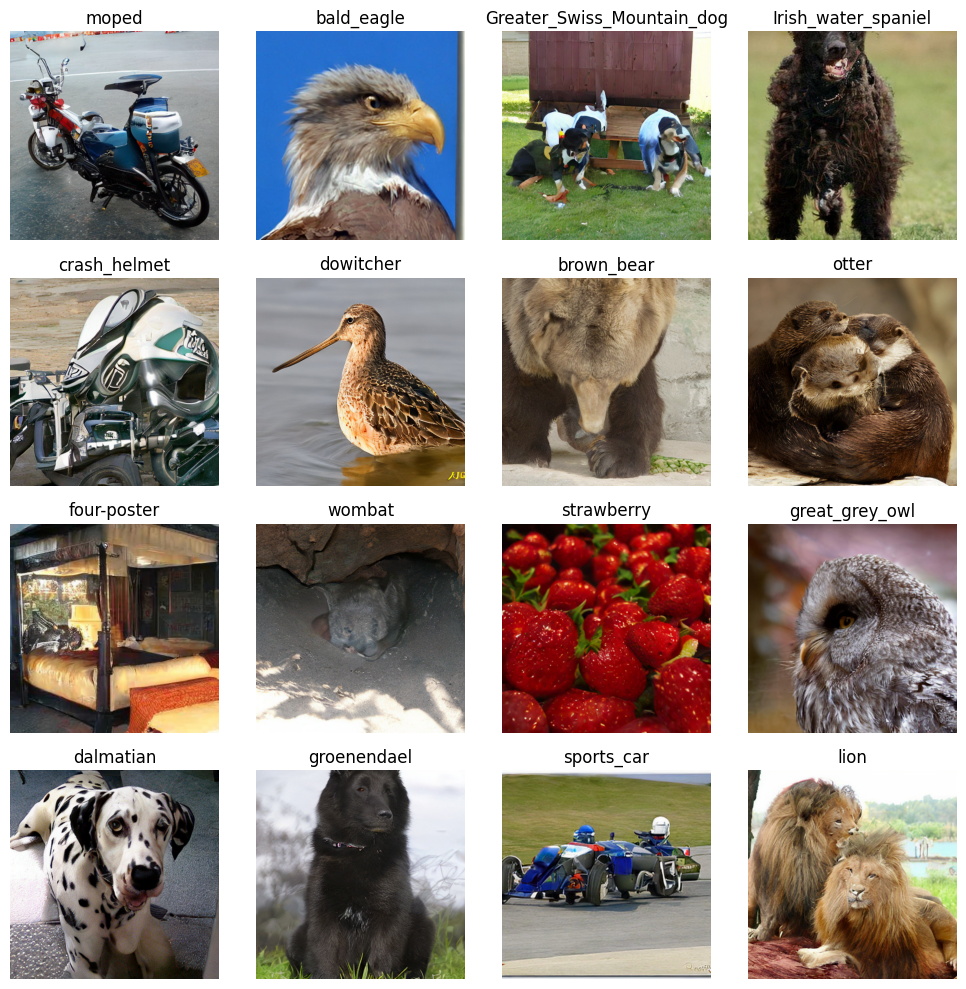

In [10]:
config = {
    # checkpoint paths for the positive and negative networks
    'net_pos_pkl': "./checkpoints/edm2-img512-s-2147483-0.100.pkl",
    'net_neg_pkl': None,
    # class index for sampling (None = random)
    'class_idx': None,
    # number of denoising steps
    'num_steps': 32,
    # guidance weight/strength
    'g_weight': 0.0,
    # guidance method: 'none', 'cfg', 'swg', 'wmg', 'wmg-swg'
    'g_method': 'none',
    # sliding window guidance parameters
    'swg_sizes': None,
    'swg_steps': None,
    'masking': 0,
    # guidance interval (steps to apply guidance), optional to implement
    'g_interval': None,
}

samples_no_guidance, labels = simple_sample(
    config=config,
    seeds=seed_list,
)

print(f"Generated {samples_no_guidance.shape[0]} samples of size {samples_no_guidance.shape[1:3]}")
display_images([samples_no_guidance[i] for i in range(samples_no_guidance.shape[0])], labels=labels,
               save_name="./unguided.png")

## 🎯 Task 2: Classifier-Free Guidance Implementation

Configure the parameters for Classifier-Free Guidance (CFG) sampling.

**Your Task:** Fill in the configuration dictionary with appropriate parameters.

**Expected Outcome:** Samples should show improved class adherence and overall quality compared to unguided samples.


Seeds: [3079, 3618, 13754, 13443, 7411, 15645, 7899, 7522, 13847, 13911, 18337, 10465, 11791, 17541, 17605, 1084]
Guidance: cfg (weight: 2.0)
Loading positive network from ./checkpoints/edm2-img512-s-2147483-0.100.pkl ...
Starting sampling...
Decoding samples...


d:\projects\uni\generative-models\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Sampling completed!
Generated 16 samples with CFG guidance


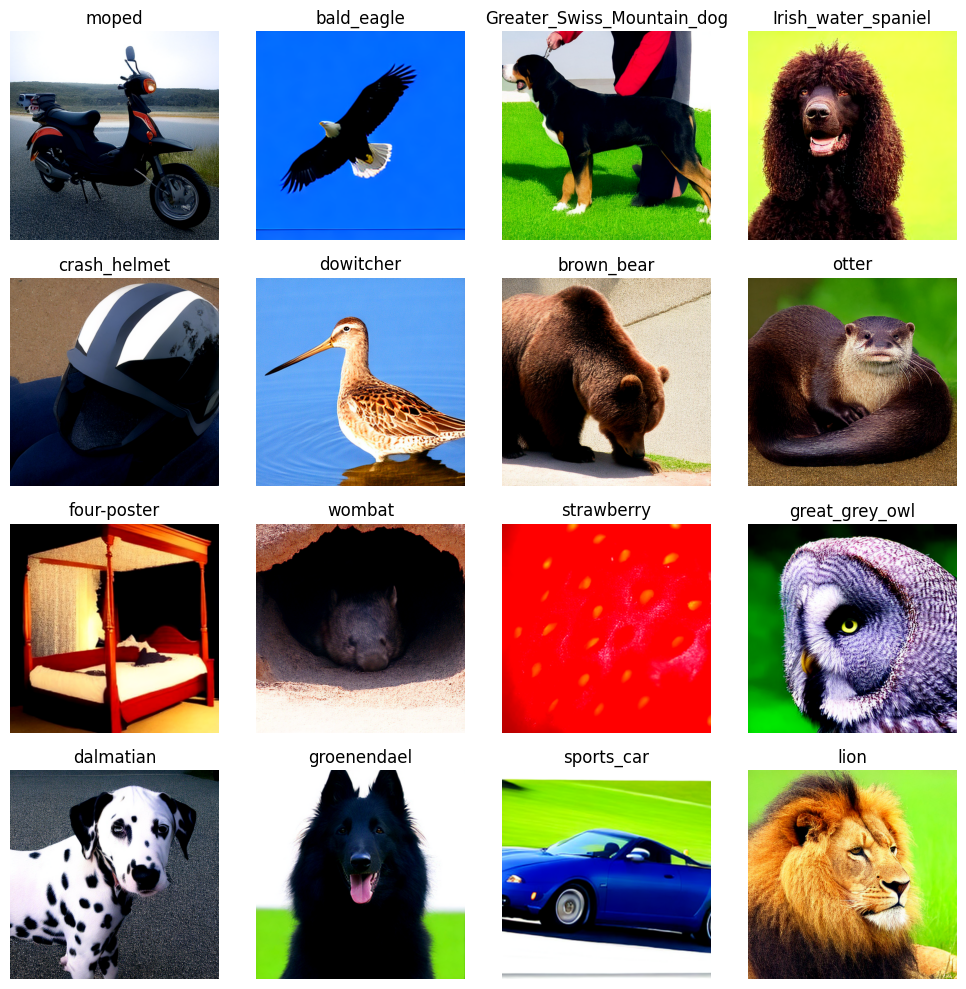

In [11]:
### START CODE HERE ###
config = {
    # checkpoint paths for the positive and negative networks
    'net_pos_pkl': "./checkpoints/edm2-img512-s-2147483-0.100.pkl",
    'net_neg_pkl': None,  # CFG uses the positive network with null labels, no separate negative model needed
    # class index for sampling (None = random)
    'class_idx': None,
    # number of denoising steps
    'num_steps': 32,
    # guidance weight/strength
    'g_weight': 2.0,  # Typical CFG scales range from 1.5 to 7.0
    # guidance method: 'none', 'cfg', 'swg', 'wmg', 'wmg-swg'
    'g_method': 'cfg',
    # sliding window guidance parameters (not used for standard CFG)
    'swg_sizes': None,
    'swg_steps': None,
    'masking': 0,
    # guidance interval (steps to apply guidance)
    'g_interval': None,
}
### END CODE HERE ###
samples_cfg, labels = simple_sample(
    config=config,
    seeds=seed_list)

print(f"Generated {samples_cfg.shape[0]} samples with CFG guidance")
display_images([samples_cfg[i] for i in range(samples_cfg.shape[0])],
               labels=labels,
               save_name=f"./cfg_samples_{float(config['g_weight']):.2f}.png")

### 🎯 Task 3: Weak Model Guidance (WMG) Configuration and sampling

Set up Weak Model Guidance (WMG) using an early training checkpoint as the "weak" model.

**Your Task:** Configure the parameters for WMG.


Seeds: [3079, 3618, 13754, 13443, 7411, 15645, 7899, 7522, 13847, 13911, 18337, 10465, 11791, 17541, 17605, 1084]
Guidance: wmg (weight: 2.0)
Loading positive network from ./checkpoints/edm2-img512-s-2147483-0.100.pkl ...
Loading negative network... ./checkpoints/edm2-img512-s-0134217-0.100.pkl
Starting sampling...
Decoding samples...


d:\projects\uni\generative-models\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Sampling completed!
Generated 16 samples with WMG guidance


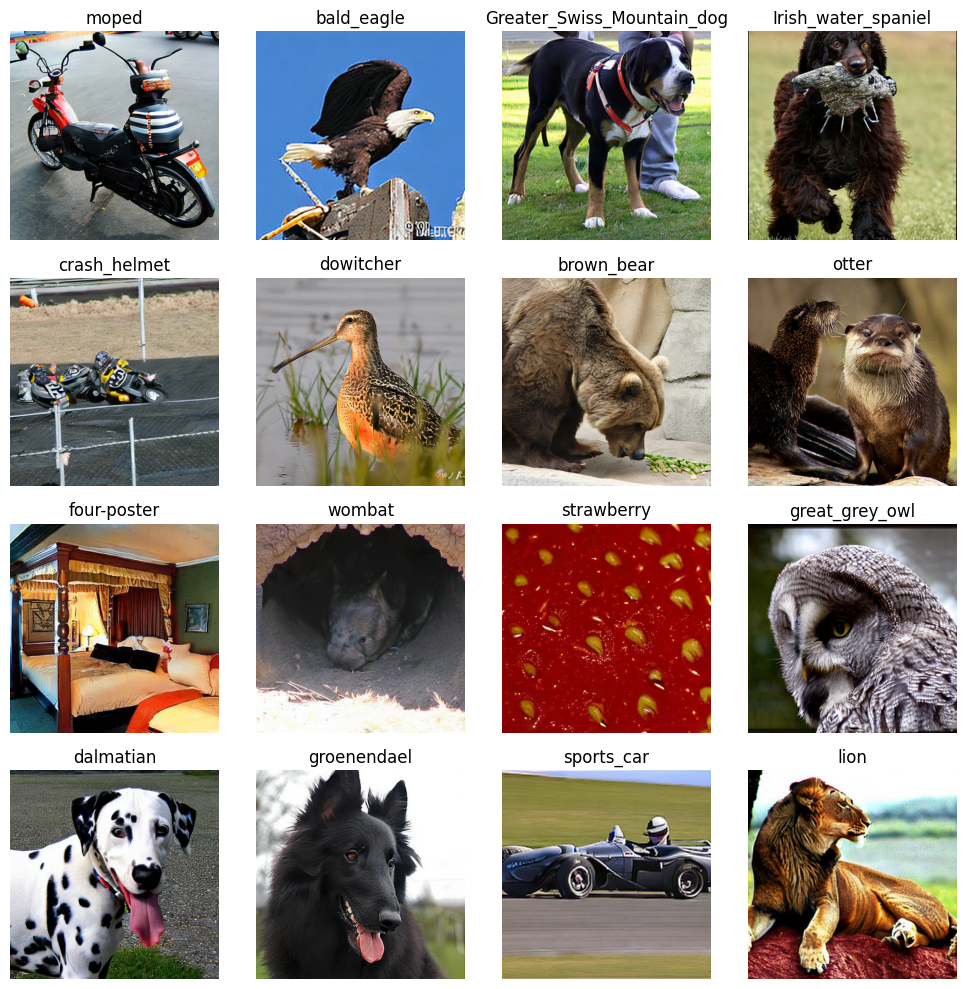

In [13]:
### START CODE HERE ###
config = {
    # Positive network: Fully trained model (2.1M iterations)
    'net_pos_pkl': "./checkpoints/edm2-img512-s-2147483-0.100.pkl",

    # Negative network: Early checkpoint (134k iterations) - The "Weak" Model
    'net_neg_pkl': "./checkpoints/edm2-img512-s-0134217-0.100.pkl",

    # Class index (None = random)
    'class_idx': None,

    # Number of steps
    'num_steps': 32,

    # Guidance weight
    'g_weight': 2.0,

    # Method
    'g_method': 'wmg',

    # SWG parameters (unused for standard WMG)
    'swg_sizes': None,
    'swg_steps': None,
    'masking': 0,

    # Guidance interval
    'g_interval': None,
}
### END CODE HERE ###
samples_cfg, labels = simple_sample(
    config=config,
    seeds=seed_list)

print(f"Generated {samples_cfg.shape[0]} samples with WMG guidance")
display_images([samples_cfg[i] for i in range(samples_cfg.shape[0])],
               labels=labels,
               save_name=f"./wmg_samples_{float(config['g_weight']):.2f}.png")

## 🎯 Task 4: Sliding Window Guidance Implementation

Implement the Sliding Window Guidance (SWG) technique, which generates guidance by comparing full-image predictions with crop-based predictions from the same model.

### Algorithm Overview:
1. **Crop Generation:** Extract multiple overlapping crops from the input image
2. **Individual Predictions:** Get model predictions for each crop separately
3. **Aggregation:** Combine crop predictions back into full-image space
4. **Masking:** Track pixel overlap frequency for weighted averaging
5. **Guidance:** Use the difference between full-image and aggregated crop predictions

### Key Parameters:
- `swg_sizes`: Size of crops (e.g., 40x40 pixels)
- `swg_steps`: Number of crops per dimension (e.g., 2 = 2x2 grid)
- `masking`: Whether to apply overlap-based masking

**Implementation Focus:** Complete the `swg_guidance` function to handle crop extraction, prediction aggregation, and mask generation.

SWG guidance function defined!
Seeds: [3079, 3618, 13754, 13443, 7411, 15645, 7899, 7522, 13847, 13911, 18337, 10465, 11791, 17541, 17605, 1084]
Guidance: swg (weight: 1.5)
Loading positive network from ./checkpoints/edm2-img512-s-2147483-0.100.pkl ...
Starting sampling...
Decoding samples...


d:\projects\uni\generative-models\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Sampling completed!
Generated 16 samples with SWG guidance


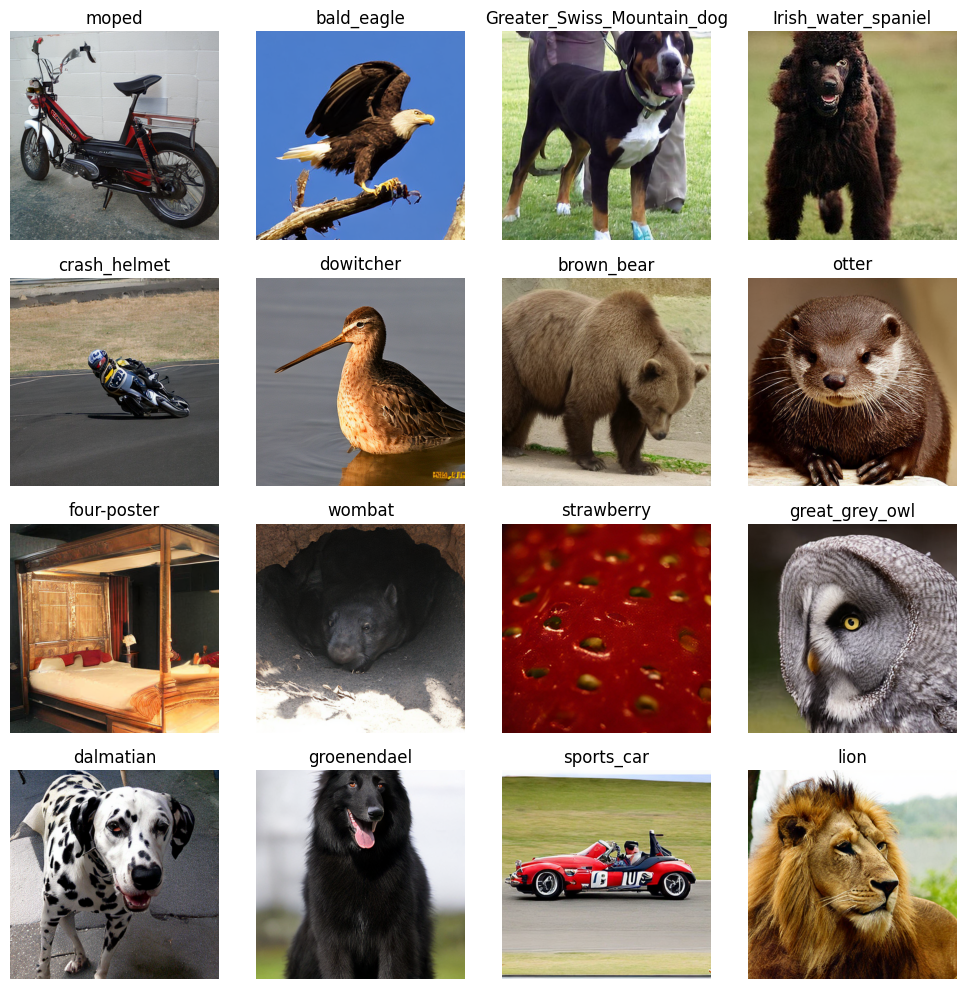

In [7]:
# SWG Guidance function
def swg_guidance(x, t, labels, net, swg_sizes, swg_steps, dtype=torch.float32):
    """
    Args:
        x: noisy image tensor of shape (bs, c, h, w)
        t: time step tensor of shape (bs,)
        labels: class labels tensor of shape (bs, label_dim)
        net: the diffusion model network
        swg_sizes: crop/kernel size for SWG
        swg_steps: number of steps (crops) per dimension
        dtype: data type for computations
    Returns:
        y_neg: negative prediction
        mask: shows how many times each pixel location has been used as part of a crop
            i.e. In the case of a corner pixel , the value wil be 1,
            which means that only one crop has used this pixel.
    """
    bs, c, img_size, _ = x.shape
    y_neg = torch.zeros_like(x)  # for negative guidance
    w = torch.zeros_like(x)      # for averaging weights

    if not isinstance(swg_sizes, int):
        swg_sizes = swg_sizes[0]
    if not isinstance(swg_steps, int):
        swg_steps = swg_steps[0]

    assert swg_steps in [1, 2, 3, 5], f'Invalid crop steps: {swg_steps}'
    swg_sizes = [swg_sizes] if isinstance(swg_sizes, int) else swg_sizes

    ### START CODE HERE ###
    # Iterate over defined crop sizes
    for crop_size in swg_sizes:
        # Determine stride (shift)
        if swg_steps > 1:
            stride = (img_size - crop_size) // (swg_steps - 1)
        else:
            stride = 0

        # Grid loop (Rows i, Columns j)
        for i in range(swg_steps):
            for j in range(swg_steps):
                # Calculate top-left coordinates (sx, sy)
                sx = i * stride
                sy = j * stride

                # Correct for last step potentially missing pixels due to integer math
                if i == swg_steps - 1: sx = img_size - crop_size
                if j == swg_steps - 1: sy = img_size - crop_size

                ex = sx + crop_size
                ey = sy + crop_size

                # Extract the crop
                x_crop = x[:, :, sx:ex, sy:ey]

                # Run the model on the crop
                # Temporarily set resolution to match crop size
                net.img_resolution = crop_size
                y_crop = net(x_crop, t, labels).to(dtype)

                # Accumulate results
                y_neg[:, :, sx:ex, sy:ey] += y_crop
                w[:, :, sx:ex, sy:ey] += 1.0

    # Normalize the aggregated prediction by the weight map (overlap count)
    y_neg = y_neg / w.clamp(min=1.0)

    # Create the binary mask
    # 1.0 where pixels overlapped (w > 1), 0.0 where they didn't (w <= 1, usually borders)
    mask = (w > 1).float()
    ### END CODE HERE ###

    net.img_resolution = img_size
    return y_neg, mask

print("SWG guidance function defined!")

config = {
    'net_pos_pkl': "./checkpoints/edm2-img512-s-2147483-0.100.pkl",
    'net_neg_pkl': None,
    'class_idx': None,
    'num_steps': 32,
    'g_weight': 1.5,
    'g_method': 'swg',
    'swg_sizes': 40,
    'swg_steps': 2,
    'masking': 1,
    'g_interval': None,
}

samples_swg, labels = simple_sample(
    config=config,
    seeds=seed_list)

print(f"Generated {samples_swg.shape[0]} samples with SWG guidance")
display_images([samples_swg[i] for i in range(samples_swg.shape[0])], labels=labels,
               save_name=f"./swg_samples_{float(config['g_weight']):.2f}.png")